In [1]:
import pandas as pd


In [3]:
datos = pd.read_excel("RomeHousing-History.xlsx", )
datos.head()

/opt/anaconda3/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,House_ID,Neighborhood,Property_type,Rooms,Surface,Elevator,Floor_type,Floor_number,Rent
0,103501,Cassia,Flat,2,65,0,Upper,2.0,900
1,105122,Collatino,Flat,2,30,1,Ground floor,0.0,500
2,104125,Collatino,Flat,3,80,1,Upper,4.0,950
3,104675,Infernetto,Flat,3,75,0,Upper,2.0,800
4,102481,Ostia,Flat,3,70,1,Ground floor,0.0,800


array([[<Axes: title={'center': 'House_ID'}>,
        <Axes: title={'center': 'Rooms'}>],
       [<Axes: title={'center': 'Surface'}>,
        <Axes: title={'center': 'Elevator'}>],
       [<Axes: title={'center': 'Floor_number'}>,
        <Axes: title={'center': 'Rent'}>]], dtype=object)

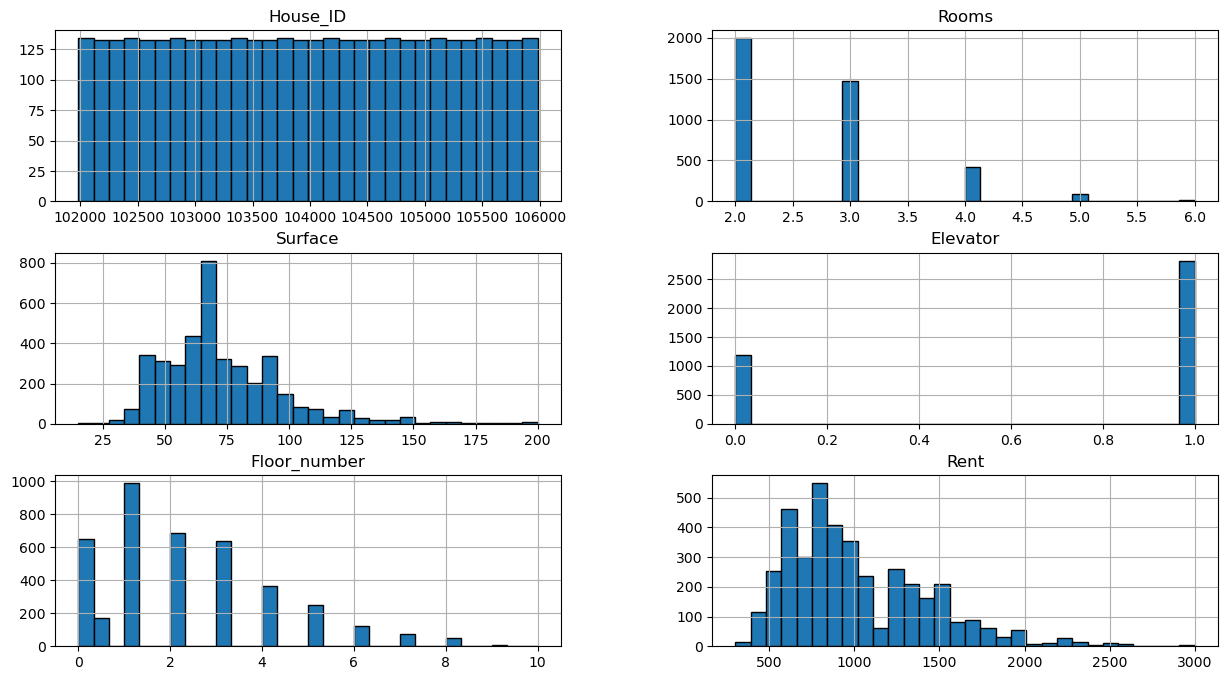

In [4]:
datos.hist(figsize=(15,8), bins=30, edgecolor="black")

Prima distinzione fondamentale: feature utili vs non utili.

House_ID → da escludere. È un identificativo, non contiene informazione predittiva.

Rent → target (y).

Tutte le altre → feature (X)

In [5]:
X = datos.drop(columns=["Rent", "House_ID"])
y = datos["Rent"]


Ora guardiamo le feature:

Numeriche:

Rooms

Surface

Elevator (binaria, va bene così)

Floor_number

Categoriche:

Neighborhood

Property_type

Floor_type

Una regressione lineare non può usare stringhe, quindi serve:

scaling per le numeriche

one-hot encoding per le categoriche

Il modo corretto (robusto, da produzione) è una Pipeline con ColumnTransformer.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


split

test_size=0.2 → il 20% dei dati va nel test set, il restante 80% nel train set

random_state=42 → imposta un seed per il generatore casuale, in modo che la divisione sia riproducibile. Usando lo stesso numero otterrai sempre la stessa suddivisione.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [8]:
#separo colonne
num_cols = X.select_dtypes(include="number").columns
cat_cols = X.select_dtypes(exclude="number").columns


In [23]:
num_cols

Index(['Rooms', 'Surface', 'Elevator', 'Floor_number'], dtype='object')

In [24]:
cat_cols

Index(['Neighborhood', 'Property_type', 'Floor_type'], dtype='object')

In [9]:
#preprocessing
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first"), cat_cols)
    ]
)


Spiegazione:

la riga crea un oggetto ColumnTransformer, che serve a preprocessare automaticamente le colonne del dataset in modo differenziato, senza dover trasformare manualmente ogni colonna. È fondamentale quando il dataset ha sia variabili numeriche sia categoriche. Vediamo pezzo per pezzo.

"num" → nome arbitrario della trasformazione per le colonne numeriche

StandardScaler() → standardizza le colonne numeriche: sottrae la media e divide per la deviazione standard. Così tutte le feature numeriche hanno media 0 e varianza 1, utile per regressione e altri modelli lineari.

num_cols → lista delle colonne numeriche (es. Rooms, Surface, Floor_number, Elevator)

"cat" → nome arbitrario della trasformazione per le colonne categoriche

OneHotEncoder(drop="first") → trasforma le categorie in variabili binarie (dummy variables). drop="first" evita la collinearità perfetta rimuovendo la prima categoria come baseline.

cat_cols → lista delle colonne categoriche (es. Neighborhood, Property_type, Floor_type)


**Cosa fa preprocess in pratica:**

Le colonne numeriche vengono scalate

Le colonne categoriche vengono trasformate in colonne 0/1

Tutto combinato in un unico array pronto per il modello

Mantiene la coerenza tra train e test, perché fit viene applicato solo sul training set, e transform sul test set o dati nuovi

In [10]:
#modello
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("regressor", LinearRegression())
])


In [11]:
model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Rooms', 'Surface', 'Elevator', 'Floor_number'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['Neighborhood', 'Property_type', 'Floor_type'], dtype='object'))])),
                ('regressor', LinearRegression())])

In [12]:
y_pred = model.predict(X_test)


In [13]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

mae, r2


(87.72611590924745, 0.9298020672099078)

In [17]:

nuovi_dati = pd.read_excel("RomeHousing-NewProperties.xlsx")


In [18]:
#rimuovo colonne non utili
X_new = nuovi_dati.drop(columns=["House_ID"], errors="ignore")

In [19]:
pred_rent = model.predict(X_new)

In [ ]:
#aggiungo la predizione
nuovi_dati["Rent_predicted"] = pred_rent

In [21]:
nuovi_dati.to_csv("nuove_case_con_predizioni.csv", index=False)